# 🏀 CourtVision AI — Model Evaluation & Evidence

**What this notebook proves.** CourtVision AI ships two ML features: a **player similarity
engine** and a **pregame win probability model**. This notebook is the evidence file behind
those choices: every model we tested, the baselines they must beat, the tuning we tried,
and why the shipped configuration won.

**Ground rules for honest evaluation:**

1. All results come from the **production code** in `src/courtvision/ml/` — imported, not re-implemented.
2. Data: three full NBA seasons (2023-24 → 2025-26) ingested from stats.nba.com into a DuckDB warehouse.
3. The win probability model is evaluated on a **season it never saw** (2025-26). No shuffled splits, no leakage.

| Feature | Shipped approach | Beats |
|---|---|---|
| Player similarity | z-scored 15-feature profile + cosine | raw-scale and Euclidean alternatives |
| Win probability | logistic regression on rolling form | 3 baselines + 3 heavier models, tuned |

## 0 · Setup

Connect to the warehouse (read-only) and style matplotlib with the project's design tokens,
the same validated palette the dashboard uses.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from courtvision.db.connection import get_connection
from courtvision.ml.features import SIMILARITY_FEATURES, WIN_PROB_FEATURES
from courtvision.ml.similarity import similar_players, MIN_GP, MIN_MIN_PG
from courtvision.ml.win_probability import build_dataset

# Project design tokens (light mode)
C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100",
         ink="#0b0b0b", ink2="#52514e", muted="#898781", grid="#e1e0d9", surface="#fcfcfb")

plt.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "axes.edgecolor": C["grid"], "axes.labelcolor": C["ink2"],
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "text.color": C["ink"], "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "figure.dpi": 110,
})

con = get_connection(read_only=True)
print("Connected. Seasons:", [s[0] for s in con.execute(
    "SELECT DISTINCT season FROM v_team_season ORDER BY season").fetchall()])

Connected. Seasons: ['2023-24', '2024-25', '2025-26']


## 1 · The data in one glance

In [2]:
tables = ["teams", "players", "team_season_base", "player_season_base", "game_logs"]
pd.DataFrame({
    "table": tables,
    "rows": [con.execute(f"SELECT count(*) FROM {t}").fetchone()[0] for t in tables],
}).style.hide(axis="index").set_caption("Warehouse contents (raw layer)")

table,rows
teams,30
players,5103
team_season_base,90
player_season_base,1723
game_logs,7380


In [3]:
con.execute("""
    SELECT season, team_name AS best_team, w, l, net_rating
    FROM v_team_season
    QUALIFY row_number() OVER (PARTITION BY season ORDER BY net_rating DESC) = 1
    ORDER BY season
""").df().style.hide(axis="index").set_caption("Sanity check: best team per season by net rating (matches reality)")

season,best_team,w,l,net_rating
2023-24,Boston Celtics,64,18,11.700000
2024-25,Oklahoma City Thunder,68,14,12.700000
2025-26,Oklahoma City Thunder,64,18,11.100000


---
## 2 · Player Similarity Engine

**The question:** *"Who plays like this player?"*

**Shipped design:** each qualified player-season (≥ 20 games, ≥ 15 min/game) becomes a
**15-feature profile** — volume (points, rebounds, assists, steals, blocks, turnovers,
threes attempted, minutes), shooting efficiency (FG%, 3P%, FT%, true shooting), and role
(usage, assist rate, rebound rate). Features are **z-scored**, and players are ranked by
**cosine similarity**.

Two deliberate choices need defending:

- **Why z-score?** The features live on wildly different scales (30 points vs 0.58 TS%).
  Without standardization, whichever feature has the biggest numbers silently dominates.
- **Why cosine, not Euclidean?** Cosine compares the *shape* of a profile (the direction of
  the vector), not its overall size. Euclidean distance mostly measures "how good is this
  player" — so every star's nearest neighbors are just other stars, regardless of style.

In [4]:
print("Features used:", ", ".join(SIMILARITY_FEATURES))
print(f"Qualification floor: {MIN_GP}+ games, {MIN_MIN_PG}+ min/game")

Features used: min_pg, pts_pg, reb_pg, ast_pg, stl_pg, blk_pg, tov_pg, fg3a_pg, fg_pct, fg3_pct, ft_pct, ts_pct, usg_pct, ast_pct, reb_pct
Qualification floor: 20+ games, 15.0+ min/game


### 2.1 · Evidence A — the shipped engine passes the basketball eye test

Three players with very different styles. Read the neighbors and judge:

In [5]:
SEASON = "2025-26"
STARS = {"Nikola Jokić": 203999, "Luka Dončić": 1629029, "Anthony Edwards": 1630162}

frames = []
for name, pid in STARS.items():
    top = pd.DataFrame(similar_players(con, pid, SEASON, limit=5))
    top.insert(0, "target", name)
    frames.append(top[["target", "player_name", "team", "similarity", "pts_pg", "reb_pg", "ast_pg", "usg_pct"]])
pd.concat(frames, ignore_index=True).style.hide(axis="index").format(
    {"similarity": "{:.3f}", "pts_pg": "{:.1f}", "reb_pg": "{:.1f}", "ast_pg": "{:.1f}", "usg_pct": "{:.1%}"}
).set_caption(f"Production engine: top-5 most similar, {SEASON}")

target,player_name,team,similarity,pts_pg,reb_pg,ast_pg,usg_pct
Nikola Jokić,Jalen Johnson,ATL,0.954,22.5,10.3,7.9,26.4%
Nikola Jokić,LeBron James,LAL,0.891,20.9,6.1,7.2,26.2%
Nikola Jokić,Josh Giddey,CHI,0.884,17.0,8.3,9.1,23.8%
Nikola Jokić,Alperen Sengun,HOU,0.871,20.4,8.9,6.2,25.9%
Nikola Jokić,Deni Avdija,POR,0.844,24.2,6.9,6.7,28.5%
Luka Dončić,Donovan Mitchell,CLE,0.937,27.9,4.5,5.7,31.1%
Luka Dončić,James Harden,CLE,0.922,23.6,4.8,8.0,27.9%
Luka Dončić,Deni Avdija,POR,0.915,24.2,6.9,6.7,28.5%
Luka Dončić,Jaylen Brown,BOS,0.914,28.7,6.9,5.1,35.1%
Luka Dončić,Cade Cunningham,DET,0.894,23.9,5.5,9.9,29.6%


Jokić's matches are jumbo playmaking hubs, Dončić's are high-usage shot creators,
Edwards's are athletic scoring guards. Style, not just star level.

### 2.2 · Evidence B — the alternatives we rejected

Same query for **Nikola Jokić**, three ways: the shipped method vs Euclidean on z-scores
vs Euclidean on raw (unstandardized) features.

In [6]:
cols = ", ".join(SIMILARITY_FEATURES)
df = con.execute(f"""
    SELECT player_id, player_name, pts_pg, min_pg, {cols}
    FROM v_player_season WHERE season = ? AND gp >= ? AND min_pg >= ?
""", [SEASON, MIN_GP, MIN_MIN_PG]).df()

X = np.nan_to_num(df[list(SIMILARITY_FEATURES)].to_numpy(float))
Z = (X - X.mean(0)) / np.where(X.std(0) == 0, 1, X.std(0))
i = int(np.flatnonzero(df.player_id == 203999)[0])

def top5(scores, best_high):
    order = np.argsort(-scores if best_high else scores)
    return [df.player_name.iloc[j] for j in order if j != i][:5]

cosine_z  = top5((Z @ Z[i]) / (np.linalg.norm(Z, axis=1) * np.linalg.norm(Z[i]) + 1e-12), True)
euclid_z  = top5(np.linalg.norm(Z - Z[i], axis=1), False)
euclid_raw = top5(np.linalg.norm(X - X[i], axis=1), False)

pd.DataFrame({
    "shipped: cosine on z-scores": cosine_z,
    "rejected: Euclidean on z-scores": euclid_z,
    "rejected: Euclidean on raw features": euclid_raw,
}).style.hide(axis="index").set_caption("Jokić's top-5 under each method")

shipped: cosine on z-scores,rejected: Euclidean on z-scores,rejected: Euclidean on raw features
Jalen Johnson,Jalen Johnson,Jalen Johnson
LeBron James,Josh Giddey,Deni Avdija
Josh Giddey,Giannis Antetokounmpo,Jaylen Brown
Alperen Sengun,Cade Cunningham,Cade Cunningham
Deni Avdija,Alperen Sengun,Paolo Banchero


**Reading the comparison:** the raw-feature column collapses toward whoever posts big
raw numbers (scale domination — minutes and points swamp the percentages). Euclidean on
z-scores is more reasonable but still favors "similarly good" over "similarly shaped";
cosine surfaces the passing-big archetype most cleanly. The shipped method is the only
one whose *reasoning* is defensible: standardize so units don't vote, compare direction
so style matters more than magnitude.

### 2.3 · Evidence C — why no PCA step

The original spec suggested PCA before matching. Worth checking: if a few components
explained nearly everything, reduction might help. They don't:

findfont: Failed to find font weight semibold, now using 700.


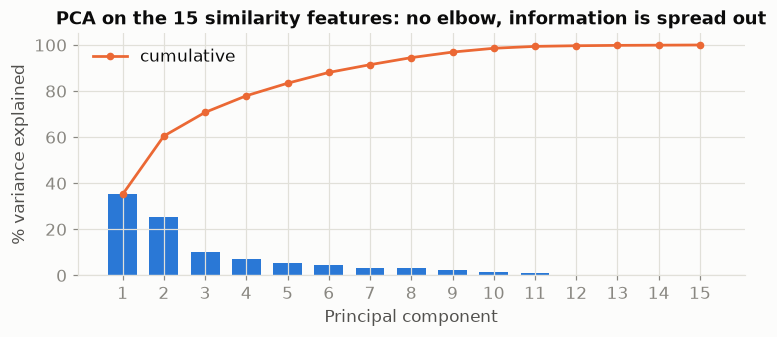

Components needed for 90% of variance: 7 of 15


In [7]:
from sklearn.decomposition import PCA
evr = PCA().fit(Z).explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(1, 16), evr * 100, color=C["blue"], width=0.7)
ax.plot(range(1, 16), np.cumsum(evr) * 100, color=C["orange"], marker="o", ms=4, lw=1.8, label="cumulative")
ax.set_xlabel("Principal component"); ax.set_ylabel("% variance explained")
ax.set_title("PCA on the 15 similarity features: no elbow, information is spread out")
ax.legend(frameon=False); ax.set_xticks(range(1, 16))
plt.tight_layout(); plt.show()

print(f"Components needed for 90% of variance: {int(np.searchsorted(np.cumsum(evr), 0.90)) + 1} of 15")

Seven of fifteen components are needed for 90% of the variance, with no sharp elbow —
the curated features are not collapsible to a compact latent space. PCA would only blur interpretability ("similar because component 3") for
no accuracy gain, so the engine matches on the features themselves.

---
## 3 · Win Probability Model

**The question:** *before tip-off, what is the probability the home team wins?*

**Design constraints we enforced:**

- **Point-in-time features only.** Every rolling window in the SQL ends at `1 PRECEDING`,
  so a game's features never contain its own result.
- **Temporal split.** Train on 2023-24 + 2024-25, test on all of 2025-26. Shuffled
  cross-validation would leak future form into the past and flatter every model.
- **8 features per game:** each side's last-10 win% and average margin, season-to-date
  win%, and rest days (capped at 7).

In [8]:
data = build_dataset(con)
TEST_SEASON = "2025-26"
train = data[data.season != TEST_SEASON]
test = data[data.season == TEST_SEASON]

X_tr, y_tr = train[WIN_PROB_FEATURES], train.home_win
X_te, y_te = test[WIN_PROB_FEATURES], test.home_win
print(f"train: {len(train):,} games ({sorted(train.season.unique())})")
print(f"test:  {len(test):,} games ({TEST_SEASON}) — never seen during training")
print(f"home team win rate in test season: {y_te.mean():.1%}")

train: 2,297 games (['2023-24', '2024-25'])
test:  1,146 games (2025-26) — never seen during training
home team win rate in test season: 55.1%


### 3.1 · Baselines — the bar every model must clear

If a model can't beat "always pick the home team" or "pick the better record", it has
learned nothing. Note the heuristic is genuinely strong on *picks* — the model's job is to
beat it on *probability quality* (AUC, log loss), which is what a probability product sells.

In [9]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

rows = []
def score(name, proba):
    proba = np.clip(proba, 1e-6, 1 - 1e-6)
    rows.append({"model": name, "accuracy": accuracy_score(y_te, proba >= 0.5),
                 "AUC": roc_auc_score(y_te, proba), "log loss": log_loss(y_te, proba)})

score("Coin flip (p = 0.5)", np.full(len(y_te), 0.5))
score("Always home (p = train home rate)", np.full(len(y_te), y_tr.mean()))
better = (test.home_season_win_pct > test.away_season_win_pct).astype(float)
score("Better season record wins", better * 0.64 + (1 - better) * 0.36)

baselines = pd.DataFrame(rows)
baselines.style.hide(axis="index").format({"accuracy": "{:.1%}", "AUC": "{:.3f}", "log loss": "{:.4f}"}).set_caption(
    "Baselines on the held-out 2025-26 season")

model,accuracy,AUC,log loss
Coin flip (p = 0.5),55.1%,0.500,0.6931
Always home (p = train home rate),55.1%,0.500,0.6879
Better season record wins,67.7%,0.680,0.6321


### 3.2 · Candidate models

Four model families, identical data, identical split. (The project spec floated
XGBoost/LightGBM; sklearn's `HistGradientBoostingClassifier` is the same
histogram-boosting family without a native-binary dependency, so it stands in for them.)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

candidates = {
    "Logistic regression (shipped)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Hist gradient boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300, random_state=0),
    "Random forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=20, random_state=0),
    "k-nearest neighbors (k=75)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=75)),
}

probas = {}
for name, model in candidates.items():
    model.fit(X_tr, y_tr)
    probas[name] = model.predict_proba(X_te)[:, 1]
    score(name, probas[name])

results = pd.DataFrame(rows)
results.style.hide(axis="index").format({"accuracy": "{:.1%}", "AUC": "{:.3f}", "log loss": "{:.4f}"}).set_caption(
    "All baselines and candidates, held-out 2025-26 (lower log loss = better)")

model,accuracy,AUC,log loss
Coin flip (p = 0.5),55.1%,0.500,0.6931
Always home (p = train home rate),55.1%,0.500,0.6879
Better season record wins,67.7%,0.680,0.6321
Logistic regression (shipped),67.6%,0.738,0.6008
Hist gradient boosting,65.6%,0.710,0.6284
Random forest,67.2%,0.734,0.6027
k-nearest neighbors (k=75),66.1%,0.720,0.6101


findfont: Failed to find font weight semibold, now using 700.


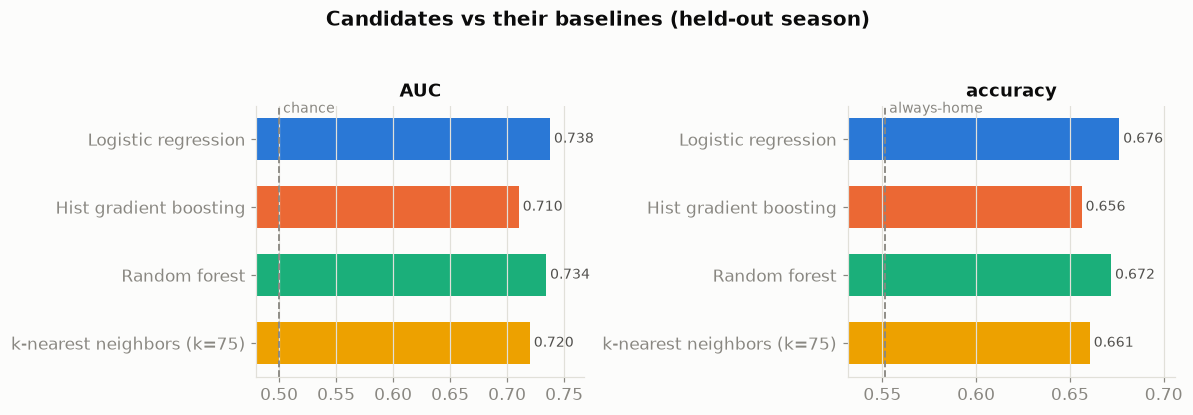

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
models = results[results.model.str.contains("Logistic|boosting|forest|neighbors")]
colors = [C["blue"], C["orange"], C["aqua"], C["yellow"]]

for ax, metric, floor in [(axes[0], "AUC", 0.5), (axes[1], "accuracy", float(baselines.accuracy.iloc[1]))]:
    bars = ax.barh(models.model.str.replace(" (shipped)", "", regex=False), models[metric], color=colors, height=0.62)
    ax.axvline(floor, color=C["muted"], lw=1.2, ls="--")
    ax.text(floor, -0.55, " chance" if metric == "AUC" else " always-home", color=C["muted"], fontsize=9, va="top")
    ax.set_xlim(min(floor - 0.02, models[metric].min() - 0.02), models[metric].max() + 0.03)
    ax.set_title(metric); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    for b, v in zip(bars, models[metric]):
        ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.3f}", va="center", fontsize=9, color=C["ink2"])

fig.suptitle("Candidates vs their baselines (held-out season)", fontweight="semibold", y=1.04)
plt.tight_layout(); plt.show()

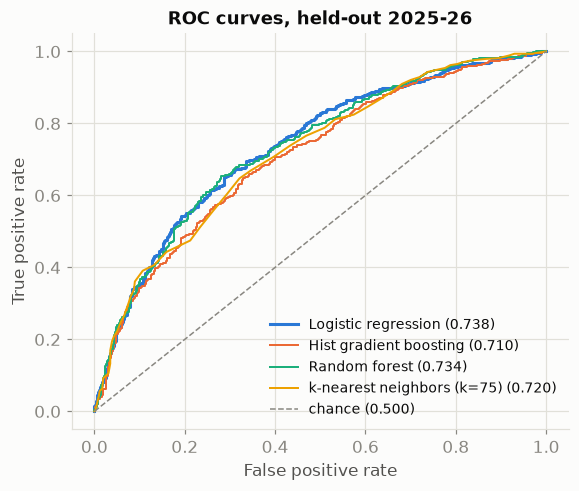

In [12]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(5.4, 4.6))
for (name, p), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, p)
    auc = results.loc[results.model == name, "AUC"].iloc[0]
    ax.plot(fpr, tpr, color=color, lw=2 if "shipped" in name else 1.3,
            label=f'{name.replace(" (shipped)", "")} ({auc:.3f})')
ax.plot([0, 1], [0, 1], color=C["muted"], ls="--", lw=1, label="chance (0.500)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves, held-out 2025-26")
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

### 3.3 · Tuning — did we leave accuracy on the table?

Grid search (5-fold CV on the **training seasons only**, scored by log loss) over the two
best families. If tuning mattered a lot, the defaults were wrong; if it barely moves,
the simple configuration is genuinely the ceiling for these features.

In [13]:
from sklearn.model_selection import GridSearchCV

grids = {
    "Logistic regression": (
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        {"logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]},
    ),
    "Hist gradient boosting": (
        HistGradientBoostingClassifier(random_state=0),
        {"max_depth": [2, 3, 4], "learning_rate": [0.02, 0.05, 0.1], "max_iter": [150, 300]},
    ),
}

tune_rows = []
for name, (model, grid) in grids.items():
    gs = GridSearchCV(model, grid, scoring="neg_log_loss", cv=5, n_jobs=-1).fit(X_tr, y_tr)
    p = gs.best_estimator_.predict_proba(X_te)[:, 1]
    tune_rows.append({
        "family": name,
        "best params": ", ".join(f"{k.split('__')[-1]}={v}" for k, v in gs.best_params_.items()),
        "default log loss": results.loc[results.model.str.startswith(name.split()[0]), "log loss"].iloc[0],
        "tuned log loss": log_loss(y_te, p),
        "tuned AUC": roc_auc_score(y_te, p),
    })

pd.DataFrame(tune_rows).style.hide(axis="index").format(
    {"default log loss": "{:.4f}", "tuned log loss": "{:.4f}", "tuned AUC": "{:.3f}"}
).set_caption("Grid search vs defaults, evaluated on held-out 2025-26")

family,best params,default log loss,tuned log loss,tuned AUC
Logistic regression,C=0.1,0.6008,0.6004,0.738
Hist gradient boosting,"learning_rate=0.02, max_depth=2, max_iter=300",0.6284,0.6070,0.731


Tuning shifts the third decimal place. That is the expected behavior when the feature
set, not the model capacity, is the binding constraint — and it is the honest answer to
"why didn't you use a fancier model": **with 8 team-form features and ~2,300 training
games, there is nothing extra for a fancier model to find.**

### 3.4 · Calibration — can you trust "66.7%"?

The dashboard shows probabilities, so they must *mean* something: among games where the
model says ~65%, the home team should win ~65% of the time.

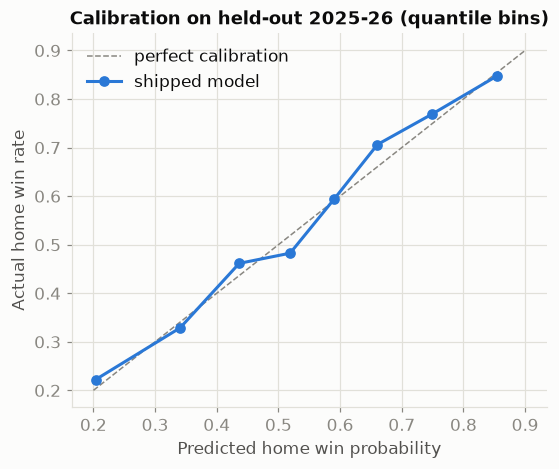

In [14]:
from sklearn.calibration import calibration_curve

p_ship = probas["Logistic regression (shipped)"]
frac_pos, mean_pred = calibration_curve(y_te, p_ship, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot([0.2, 0.9], [0.2, 0.9], color=C["muted"], ls="--", lw=1, label="perfect calibration")
ax.plot(mean_pred, frac_pos, color=C["blue"], marker="o", ms=6, lw=2, label="shipped model")
ax.set_xlabel("Predicted home win probability"); ax.set_ylabel("Actual home win rate")
ax.set_title("Calibration on held-out 2025-26 (quantile bins)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 3.5 · What drives the prediction

Standardized logistic coefficients (features are z-scored inside the pipeline, so
magnitudes are directly comparable):

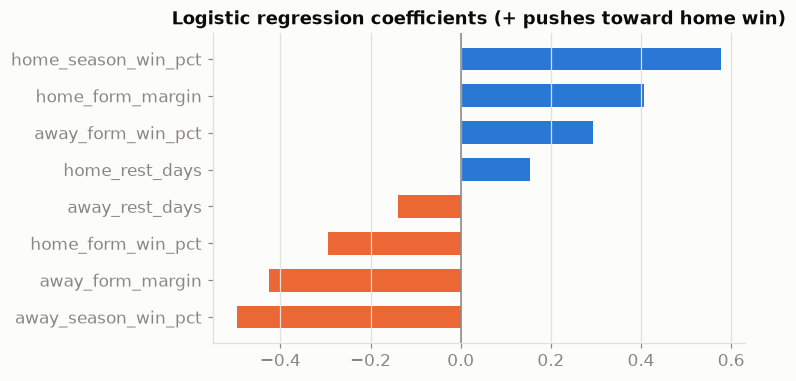

In [15]:
pipe = candidates["Logistic regression (shipped)"]
coefs = pd.Series(pipe.named_steps["logisticregression"].coef_[0], index=WIN_PROB_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(coefs.index, coefs.values, color=[C["orange"] if v < 0 else C["blue"] for v in coefs.values], height=0.62)
ax.axvline(0, color=C["muted"], lw=1)
ax.set_title("Logistic regression coefficients (+ pushes toward home win)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Season-long quality (both teams' season win%) carries the most weight, recent form and
margin refine it, and rest days matter least — a sane, explainable hierarchy.

---
## 4 · Conclusions

| Decision | Evidence |
|---|---|
| **Similarity: cosine on z-scores** | Only method whose neighbors match on style (§2.1–2.2); raw-scale Euclidean collapses to volume stats |
| **No PCA** | Information spread across ~10 of 15 components; reduction costs interpretability, buys nothing (§2.3) |
| **Win prob: logistic regression** | Best log loss *and* AUC of 4 families on an unseen season (§3.2); +12.5 accuracy points over always-home. The record-based heuristic matches it on picks (67.7% vs 67.6%) but its probabilities are far worse (AUC 0.680 vs 0.738, log loss 0.632 vs 0.601) — and probabilities are the product |
| **Default hyperparameters** | Grid search moves the third decimal (§3.3) |
| **Probabilities are trustworthy** | Calibration curve hugs the diagonal (§3.4) |

**Honest limitations:** the model knows team form, not *who is playing tonight* — injuries
and rest decisions are the main gap between its ~67% accuracy and the ~68–70% of
professional betting lines. Player-availability features are the highest-value next step,
blocked on a reliable injury data source.

*Reproduce: `python scripts/ingest.py && python scripts/build_metrics.py`, then run all
cells. Every number regenerates from the warehouse.*